In [41]:

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [42]:
# read the file
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [43]:
# knowing the data rows and columns
df.shape
df.info


<bound method DataFrame.info of       age     sex   bmi  children smoker     region  expenses
0      19  female  27.9         0    yes  southwest  16884.92
1      18    male  33.8         1     no  southeast   1725.55
2      28    male  33.0         3     no  southeast   4449.46
3      33    male  22.7         0     no  northwest  21984.47
4      32    male  28.9         0     no  northwest   3866.86
...   ...     ...   ...       ...    ...        ...       ...
1333   50    male  31.0         3     no  northwest  10600.55
1334   18  female  31.9         0     no  northeast   2205.98
1335   18  female  36.9         0     no  southeast   1629.83
1336   21  female  25.8         0     no  southwest   2007.95
1337   61  female  29.1         0    yes  northwest  29141.36

[1338 rows x 7 columns]>

In [44]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [45]:
df.duplicated().sum()


np.int64(1)

In [46]:
# remove duplicate
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

UNIVARIATE ANALYSIS 
CHECK AND ANALYSING THE SINGLE FEATURES

<Axes: xlabel='smoker', ylabel='count'>

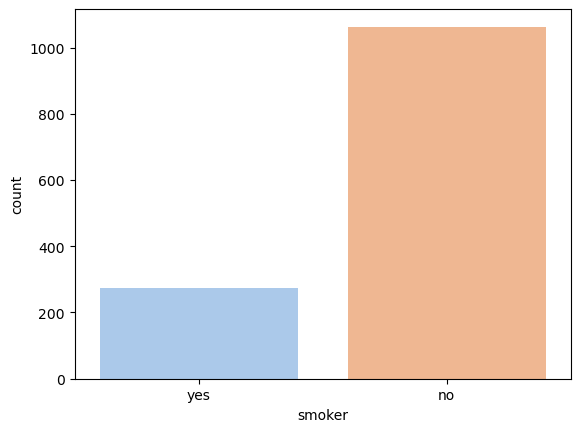

In [47]:
# to find no of smoker in dataset
sns.countplot(x='smoker', data=df, palette='pastel')

<Axes: xlabel='sex', ylabel='count'>

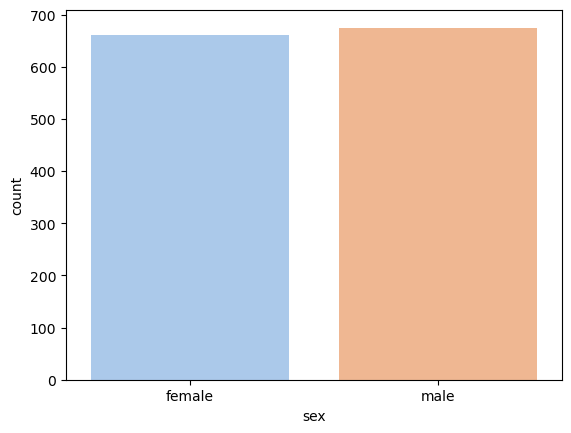

In [48]:
# to find nof female and male 
sns.countplot(x='sex', data=df, palette='pastel')

<Axes: xlabel='sex', ylabel='count'>

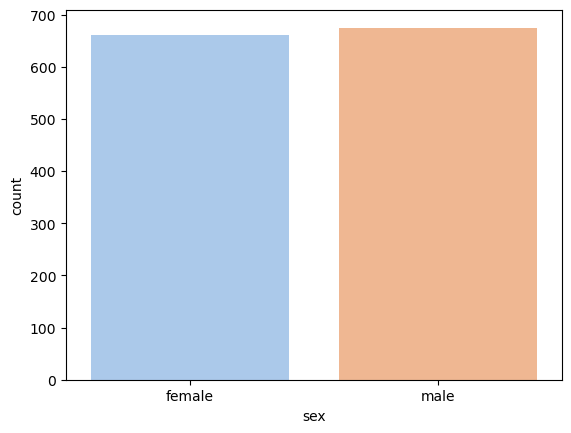

In [49]:
sns.countplot(x='sex', data=df, palette='pastel')

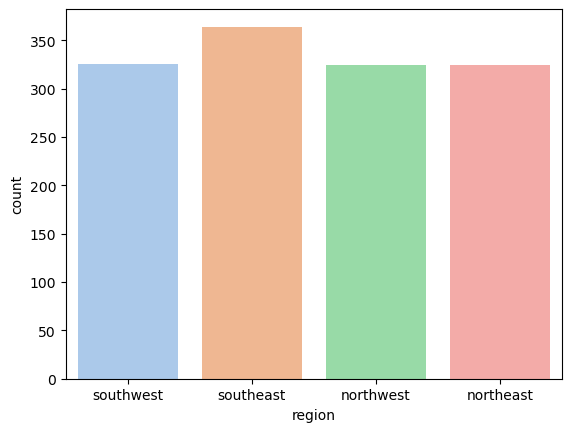

In [51]:
sns.countplot(x='region', data=df, palette='pastel')
plt.show()

<Axes: xlabel='sex', ylabel='count'>

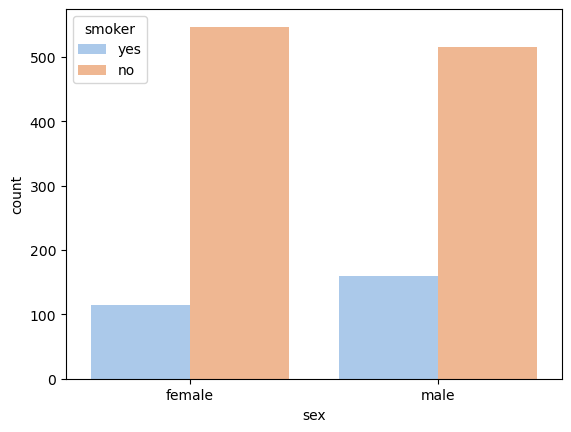

In [52]:
sns.countplot(x='sex', data=df, hue='smoker', palette='pastel')

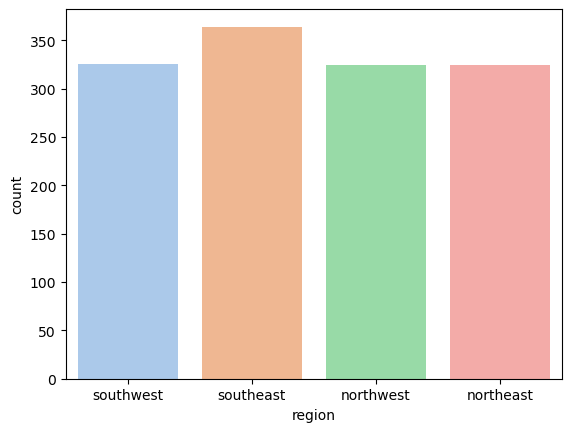

In [53]:

sns.countplot(x='region', data=df, palette='pastel')
plt.show()

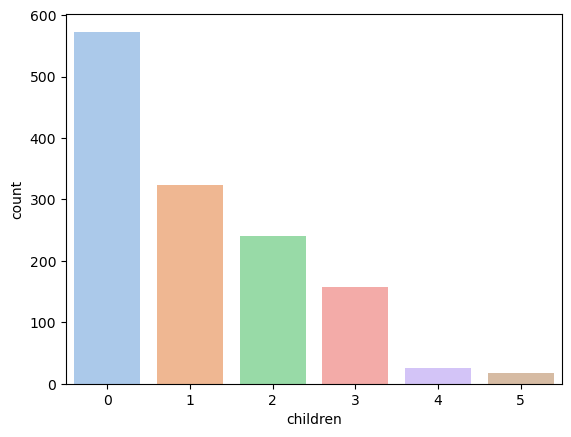

In [54]:
sns.countplot(x='children', data=df, palette='pastel')
plt.show()

<Axes: ylabel='Density'>

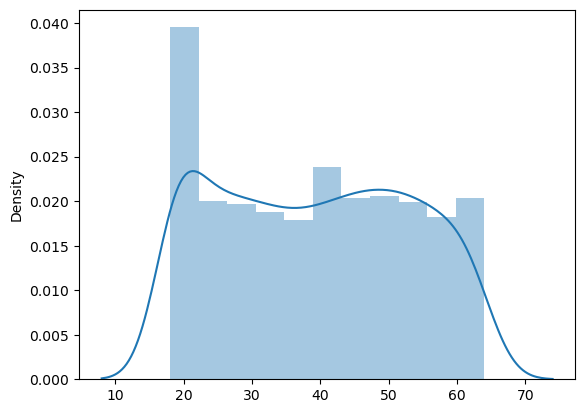

In [55]:
sns.distplot(x=df['age'])

BIVARIATE ANALYSIS 
ANALYSING THE TWO INPUT FEATURES


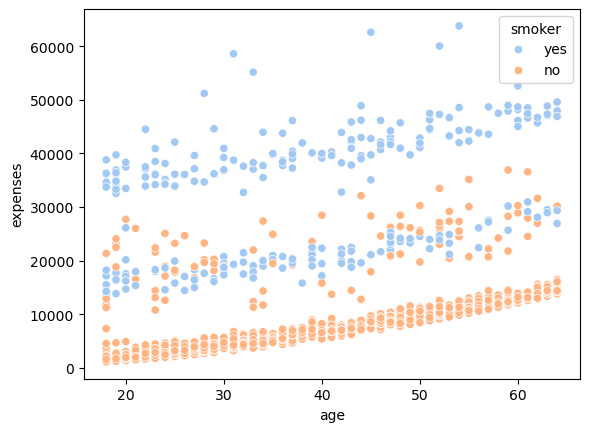

In [56]:
sns.scatterplot(x='age', y='expenses', data=df, hue='smoker', palette='pastel');
plt.show() 

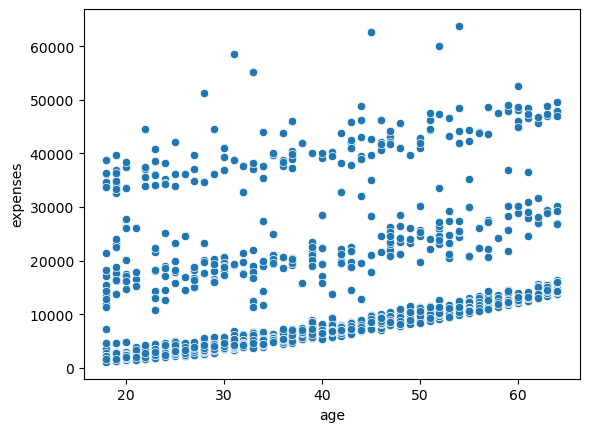

In [57]:
sns.scatterplot(x='age', y='expenses', data=df, palette='pastel');
plt.show() 

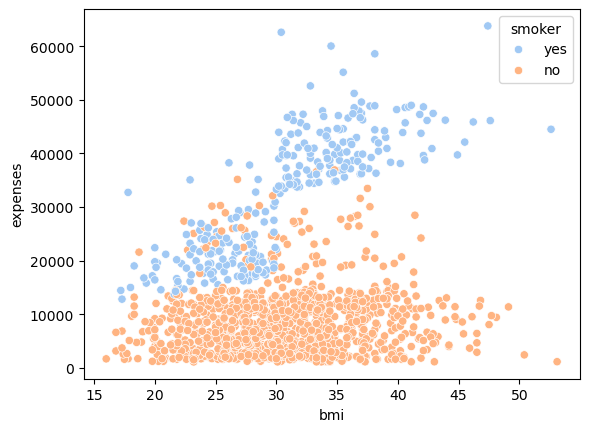

In [58]:
sns.scatterplot(x='bmi', y='expenses', data=df, hue='smoker', palette='pastel');
plt.show() 

MULTIVARIATE ANALYSIS
BY CORRELATION



In [60]:
num_fea= df[['age', 'bmi','children','expenses']]
num_fea.head()

,age,bmi,children,expenses
0,19,27.9,0,16884.92
1,18,33.8,1,1725.55
2,28,33.0,3,4449.46
3,33,22.7,0,21984.47
4,32,28.9,0,3866.86


<Axes: >

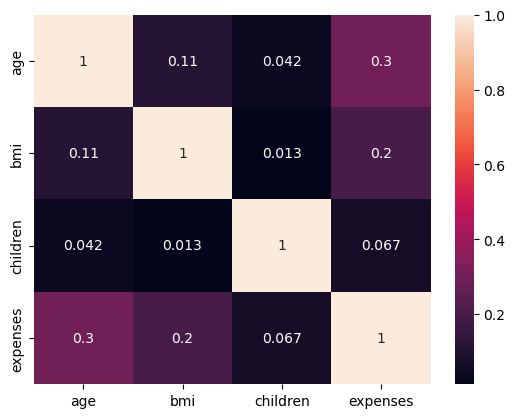

In [61]:
num_fea.corr()
sns.heatmap(num_fea.corr(),annot=True)

we need transfer the data into numbers
FEATURE TRANSFORMATION


In [63]:
# get dummies
df = pd.get_dummies(df, drop_first=True)
df.head()


,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


In [64]:
df.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


In [65]:
# seperate independent and dependent features
X = df.drop('expenses', axis=1) #independent
y = df['expenses']#dependent
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,False,True,False,False,True
1,18,33.8,1,True,False,False,True,False
2,28,33.0,3,True,False,False,True,False
3,33,22.7,0,True,False,True,False,False
4,32,28.9,0,True,False,True,False,False


FEATURES SCALING 
THERE ARE MANY WAYS
 
1.MIN-MAX [0,1]
2.STANDARD SCALING -DEPENDS ON Varience [0,2]

In [70]:

from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
X = pd.DataFrame(scalar.fit_transform(X) ,columns=X.columns)
X.head()


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.021739,0.320755,0.0,0.0,1.0,0.0,0.0,1.0
1,0.000000,0.479784,0.2,1.0,0.0,0.0,1.0,0.0
2,0.217391,0.458221,0.6,1.0,0.0,0.0,1.0,0.0
3,0.326087,0.180593,0.0,1.0,0.0,1.0,0.0,0.0
4,0.304348,0.347709,0.0,1.0,0.0,1.0,0.0,0.0


In [76]:
X.describe()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,0.461351,0.395297,0.219147,0.504862,0.204936,0.242334,0.272251,0.243082
std,0.305312,0.164438,0.241114,0.500163,0.403806,0.428655,0.445285,0.429104
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.195652,0.277628,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.456522,0.388140,0.200000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,0.717391,0.504043,0.400000,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
#  train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape,y_train.shape,y_test.shape

((1069, 8), (268, 8), (1069,), (268,))

In [77]:
# linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [78]:
from sklearn.metrics import r2_score
LR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
LR_Accuracy

81

In [79]:
#  decission tree regression
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)


DecisionTreeRegressor()

In [80]:
from sklearn.metrics import r2_score
DTR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
DTR_Accuracy

79

In [81]:
# support vector regression
from sklearn.svm import SVR
model = SVR()
model.fit(X_train, y_train)
from sklearn.metrics import r2_score
SVR_Accuracy=round(r2_score(y_test, model.predict(X_test)) * 100)
SVR_Accuracy

-13

In [83]:
# # random forese regressor with estimate
from sklearn.ensemble import RandomForestRegressor
RF_model = RandomForestRegressor(n_estimators=10)
RF_model.fit(X_train, y_train)
from sklearn.metrics import r2_score
RFR_Accuracy=round(r2_score(y_test, RF_model.predict(X_test)) * 100)
RFR_Accuracy



87

In [90]:
#  polynomial regression
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
from sklearn.linear_model import LinearRegression
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
from sklearn.metrics import r2_score
PR_Accuracy=round(r2_score(y_test, poly_model.predict(X_test_poly)) * 100)
PR_Accuracy

88

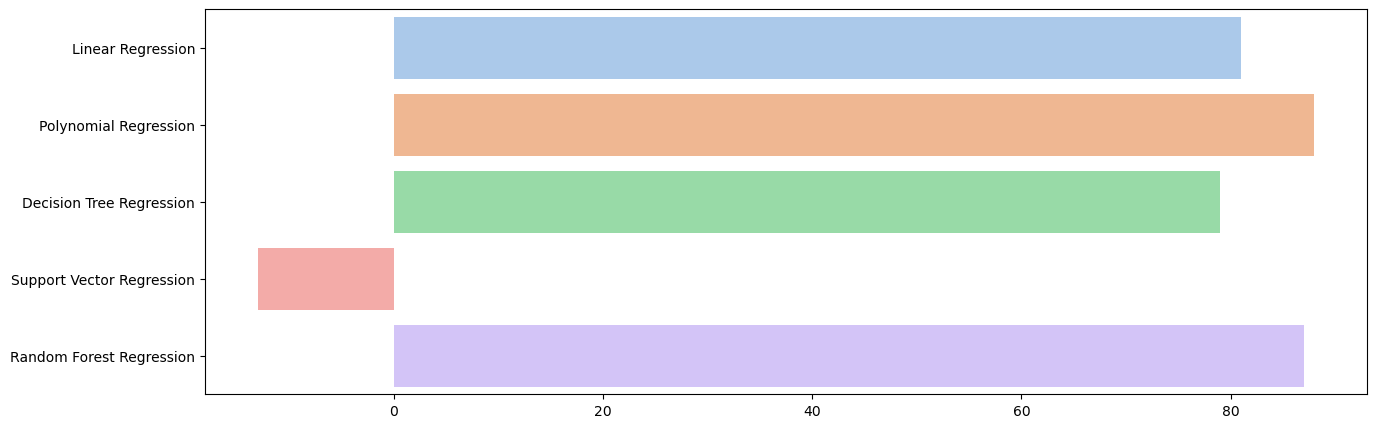

In [92]:

models = ["Linear Regression", "Polynomial Regression", "Decision Tree Regression", "Support Vector Regression", "Random Forest Regression"]
Accuracy = [LR_Accuracy,PR_Accuracy, DTR_Accuracy, SVR_Accuracy, RFR_Accuracy]
plt.figure(figsize=(15, 5))
sns.barplot(x=Accuracy, y=models, palette='pastel')
plt.show()

In [105]:
# predict the user inputs with the forest model
input_data = (19,27.9,2,0,1,0,1,0)
input_data= np.asarray(input_data)
input_data = scalar.transform(input_data.reshape(1,-1))
prediction = RF_model.predict(input_data)
print(prediction)

[19173.861]


In [106]:
# save random forest model
import pickle
pickle.dump(RF_model, open('RF_model.pkl', 'wb'))


In [107]:
# save scaler parameters
pickle.dump(scalar,open('scalar.pkl','wb'))